# 05 — Baseline Models: Random Forest and MLP

Goal:
- Train baseline regressors for the 21 cm symbolic regression project.
- Compare raw-scaled and log-scaled feature representations.
- Estimate first recoverability hierarchy across the five target parameters.

Models:
- Random Forest
- Multilayer Perceptron

Targets:
- zeta
- log10_Tvir
- R_mfp
- log10_LX
- sigma8

In [1]:
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"
RESULTS = PROJECT_ROOT / "results"
LOGS = PROJECT_ROOT / "logs"

for path in [DATA_PROCESSED, FIGURES, RESULTS, LOGS]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data:", DATA_PROCESSED)
print("Figures:", FIGURES)
print("Results:", RESULTS)

Project root: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression
Processed data: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed
Figures: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures
Results: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results


In [3]:
DATA_TAG = "n100_validation"

X_train_scaled_path = DATA_PROCESSED / f"X_train_scaled_{DATA_TAG}.npy"
X_test_scaled_path = DATA_PROCESSED / f"X_test_scaled_{DATA_TAG}.npy"

X_train_log_scaled_path = DATA_PROCESSED / f"X_train_log_scaled_{DATA_TAG}.npy"
X_test_log_scaled_path = DATA_PROCESSED / f"X_test_log_scaled_{DATA_TAG}.npy"

y_train_raw_path = DATA_PROCESSED / f"y_train_raw_{DATA_TAG}.npy"
y_test_raw_path = DATA_PROCESSED / f"y_test_raw_{DATA_TAG}.npy"

y_train_scaled_path = DATA_PROCESSED / f"y_train_scaled_{DATA_TAG}.npy"
y_test_scaled_path = DATA_PROCESSED / f"y_test_scaled_{DATA_TAG}.npy"

target_names_path = DATA_PROCESSED / f"target_names_{DATA_TAG}.csv"
target_scaler_path = DATA_PROCESSED / f"target_scaler_{DATA_TAG}.joblib"

print("Data tag:", DATA_TAG)

Data tag: n100_validation


In [4]:
X_train_scaled = np.load(X_train_scaled_path)
X_test_scaled = np.load(X_test_scaled_path)

X_train_log_scaled = np.load(X_train_log_scaled_path)
X_test_log_scaled = np.load(X_test_log_scaled_path)

y_train_raw = np.load(y_train_raw_path)
y_test_raw = np.load(y_test_raw_path)

y_train_scaled = np.load(y_train_scaled_path)
y_test_scaled = np.load(y_test_scaled_path)

target_names_df = pd.read_csv(target_names_path)
target_names = target_names_df["target_name"].tolist()

target_scaler = joblib.load(target_scaler_path)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("X_train_log_scaled:", X_train_log_scaled.shape)
print("X_test_log_scaled:", X_test_log_scaled.shape)

print("y_train_raw:", y_train_raw.shape)
print("y_test_raw:", y_test_raw.shape)

print("Target names:", target_names)

X_train_scaled: (80, 57)
X_test_scaled: (20, 57)
X_train_log_scaled: (80, 57)
X_test_log_scaled: (20, 57)
y_train_raw: (80, 5)
y_test_raw: (20, 5)
Target names: ['zeta', 'log10_Tvir', 'R_mfp', 'log10_LX', 'sigma8']


In [5]:
assert X_train_scaled.shape == X_train_log_scaled.shape
assert X_test_scaled.shape == X_test_log_scaled.shape

assert y_train_raw.shape == y_train_scaled.shape
assert y_test_raw.shape == y_test_scaled.shape

assert y_train_raw.shape[1] == len(target_names)

assert np.all(np.isfinite(X_train_scaled))
assert np.all(np.isfinite(X_test_scaled))
assert np.all(np.isfinite(X_train_log_scaled))
assert np.all(np.isfinite(X_test_log_scaled))
assert np.all(np.isfinite(y_train_raw))
assert np.all(np.isfinite(y_test_raw))

print("Baseline input validation passed.")

Baseline input validation passed.


In [6]:
def evaluate_predictions(y_true, y_pred, target_names, model_name, feature_representation):
    rows = []

    for i, target in enumerate(target_names):
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])

        rows.append({
            "model": model_name,
            "feature_representation": feature_representation,
            "target": target,
            "r2": r2,
            "mae": mae,
        })

    return pd.DataFrame(rows)

In [7]:
rf_raw = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

rf_raw.fit(X_train_scaled, y_train_raw)

rf_raw_pred = rf_raw.predict(X_test_scaled)

rf_raw_results = evaluate_predictions(
    y_true=y_test_raw,
    y_pred=rf_raw_pred,
    target_names=target_names,
    model_name="Random Forest",
    feature_representation="raw_scaled",
)

rf_raw_results

,model,feature_representation,target,r2,mae
0,Random Forest,raw_scaled,zeta,-0.184709,16.376111
1,Random Forest,raw_scaled,log10_Tvir,0.047715,0.384969
2,Random Forest,raw_scaled,R_mfp,0.139587,5.026085
3,Random Forest,raw_scaled,log10_LX,-0.065255,0.986001
4,Random Forest,raw_scaled,sigma8,0.808639,0.017444


In [8]:
rf_log = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

rf_log.fit(X_train_log_scaled, y_train_raw)

rf_log_pred = rf_log.predict(X_test_log_scaled)

rf_log_results = evaluate_predictions(
    y_true=y_test_raw,
    y_pred=rf_log_pred,
    target_names=target_names,
    model_name="Random Forest",
    feature_representation="log_scaled",
)

rf_log_results

,model,feature_representation,target,r2,mae
0,Random Forest,log_scaled,zeta,-0.181410,16.362191
1,Random Forest,log_scaled,log10_Tvir,0.041535,0.385994
2,Random Forest,log_scaled,R_mfp,0.143433,5.018310
3,Random Forest,log_scaled,log10_LX,-0.063462,0.985332
4,Random Forest,log_scaled,sigma8,0.807925,0.017433


In [9]:
mlp_raw = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
)

mlp_raw.fit(X_train_scaled, y_train_scaled)

mlp_raw_pred_scaled = mlp_raw.predict(X_test_scaled)
mlp_raw_pred = target_scaler.inverse_transform(mlp_raw_pred_scaled)

mlp_raw_results = evaluate_predictions(
    y_true=y_test_raw,
    y_pred=mlp_raw_pred,
    target_names=target_names,
    model_name="MLP",
    feature_representation="raw_scaled",
)

mlp_raw_results

,model,feature_representation,target,r2,mae
0,MLP,raw_scaled,zeta,-0.355647,16.648795
1,MLP,raw_scaled,log10_Tvir,0.039337,0.387775
2,MLP,raw_scaled,R_mfp,-0.055116,5.581343
3,MLP,raw_scaled,log10_LX,-0.343278,1.098883
4,MLP,raw_scaled,sigma8,0.960441,0.007485


In [10]:
mlp_log = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
)

mlp_log.fit(X_train_log_scaled, y_train_scaled)

mlp_log_pred_scaled = mlp_log.predict(X_test_log_scaled)
mlp_log_pred = target_scaler.inverse_transform(mlp_log_pred_scaled)

mlp_log_results = evaluate_predictions(
    y_true=y_test_raw,
    y_pred=mlp_log_pred,
    target_names=target_names,
    model_name="MLP",
    feature_representation="log_scaled",
)

mlp_log_results

,model,feature_representation,target,r2,mae
0,MLP,log_scaled,zeta,-0.924071,20.103102
1,MLP,log_scaled,log10_Tvir,-0.073988,0.396148
2,MLP,log_scaled,R_mfp,0.175866,4.734829
3,MLP,log_scaled,log10_LX,-0.239665,1.038833
4,MLP,log_scaled,sigma8,0.925185,0.010375


In [11]:
baseline_results = pd.concat(
    [
        rf_raw_results,
        rf_log_results,
        mlp_raw_results,
        mlp_log_results,
    ],
    ignore_index=True,
)

baseline_results

,model,feature_representation,target,r2,mae
0,Random Forest,raw_scaled,zeta,-0.184709,16.376111
1,Random Forest,raw_scaled,log10_Tvir,0.047715,0.384969
2,Random Forest,raw_scaled,R_mfp,0.139587,5.026085
3,Random Forest,raw_scaled,log10_LX,-0.065255,0.986001
4,Random Forest,raw_scaled,sigma8,0.808639,0.017444
5,Random Forest,log_scaled,zeta,-0.181410,16.362191
6,Random Forest,log_scaled,log10_Tvir,0.041535,0.385994
7,Random Forest,log_scaled,R_mfp,0.143433,5.018310
8,Random Forest,log_scaled,log10_LX,-0.063462,0.985332
9,Random Forest,log_scaled,sigma8,0.807925,0.017433


In [12]:
r2_table = baseline_results.pivot_table(
    index="target",
    columns=["model", "feature_representation"],
    values="r2"
)

r2_table

model                         MLP            Random Forest           
feature_representation log_scaled raw_scaled    log_scaled raw_scaled
target                                                               
R_mfp                    0.175866  -0.055116      0.143433   0.139587
log10_LX                -0.239665  -0.343278     -0.063462  -0.065255
log10_Tvir              -0.073988   0.039337      0.041535   0.047715
sigma8                   0.925185   0.960441      0.807925   0.808639
zeta                    -0.924071  -0.355647     -0.181410  -0.184709

In [13]:
mae_table = baseline_results.pivot_table(
    index="target",
    columns=["model", "feature_representation"],
    values="mae"
)

mae_table

model                         MLP            Random Forest           
feature_representation log_scaled raw_scaled    log_scaled raw_scaled
target                                                               
R_mfp                    4.734829   5.581343      5.018310   5.026085
log10_LX                 1.038833   1.098883      0.985332   0.986001
log10_Tvir               0.396148   0.387775      0.385994   0.384969
sigma8                   0.010375   0.007485      0.017433   0.017444
zeta                    20.103102  16.648795     16.362191  16.376111

In [14]:
baseline_results_path = RESULTS / f"baseline_results_{DATA_TAG}.csv"
r2_table_path = RESULTS / f"baseline_r2_table_{DATA_TAG}.csv"
mae_table_path = RESULTS / f"baseline_mae_table_{DATA_TAG}.csv"

baseline_results.to_csv(baseline_results_path, index=False)
r2_table.to_csv(r2_table_path)
mae_table.to_csv(mae_table_path)

print("Saved baseline results:")
print(" -", baseline_results_path)
print(" -", r2_table_path)
print(" -", mae_table_path)

Saved baseline results:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/baseline_results_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/baseline_r2_table_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/baseline_mae_table_n100_validation.csv


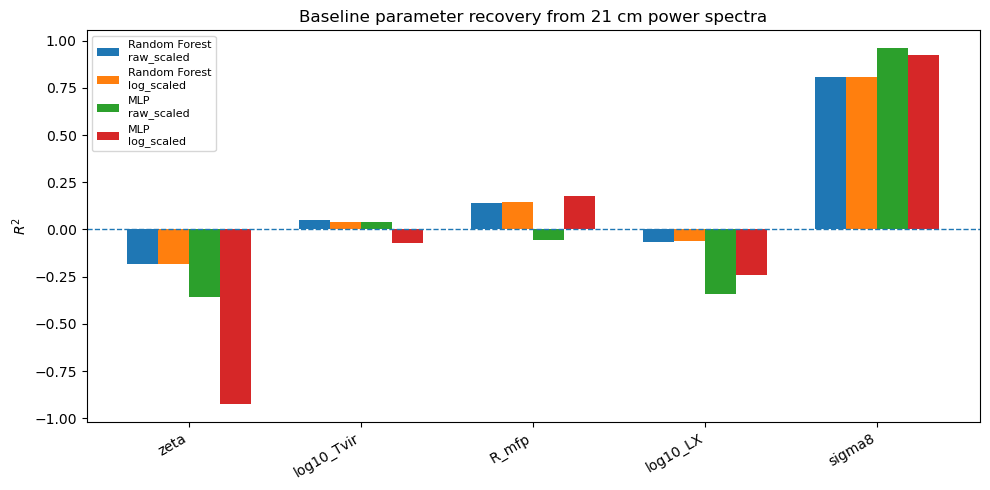

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/baseline_r2_comparison_n100_validation.png


In [15]:
plt.figure(figsize=(10, 5))

plot_df = baseline_results.copy()
plot_df["label"] = (
    plot_df["model"] + "\n" + plot_df["feature_representation"]
)

x = np.arange(len(target_names))
width = 0.18

labels = plot_df["label"].unique()

for i, label in enumerate(labels):
    sub = plot_df[plot_df["label"] == label]
    values = [sub[sub["target"] == target]["r2"].values[0] for target in target_names]

    plt.bar(
        x + (i - 1.5) * width,
        values,
        width=width,
        label=label,
    )

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xticks(x, target_names, rotation=30, ha="right")
plt.ylabel(r"$R^2$")
plt.title("Baseline parameter recovery from 21 cm power spectra")
plt.legend(fontsize=8)
plt.tight_layout()

r2_fig_path = FIGURES / f"baseline_r2_comparison_{DATA_TAG}.png"
plt.savefig(r2_fig_path, dpi=300)
plt.show()

print("Saved figure to:", r2_fig_path)

In [16]:
def plot_predicted_vs_true(y_true, predictions_dict, target_names, output_path):
    n_targets = len(target_names)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=n_targets,
        figsize=(4 * n_targets, 4),
        constrained_layout=True,
    )

    if n_targets == 1:
        axes = [axes]

    for i, target in enumerate(target_names):
        ax = axes[i]

        y_min = np.min(y_true[:, i])
        y_max = np.max(y_true[:, i])
        pad = 0.05 * (y_max - y_min)

        ax.plot(
            [y_min - pad, y_max + pad],
            [y_min - pad, y_max + pad],
            linestyle="--",
            linewidth=1,
        )

        for label, y_pred in predictions_dict.items():
            ax.scatter(
                y_true[:, i],
                y_pred[:, i],
                s=25,
                alpha=0.8,
                label=label,
            )

        ax.set_title(target)
        ax.set_xlabel("True")
        ax.set_ylabel("Predicted")

    axes[-1].legend(fontsize=8, loc="best")

    plt.savefig(output_path, dpi=300)
    plt.show()

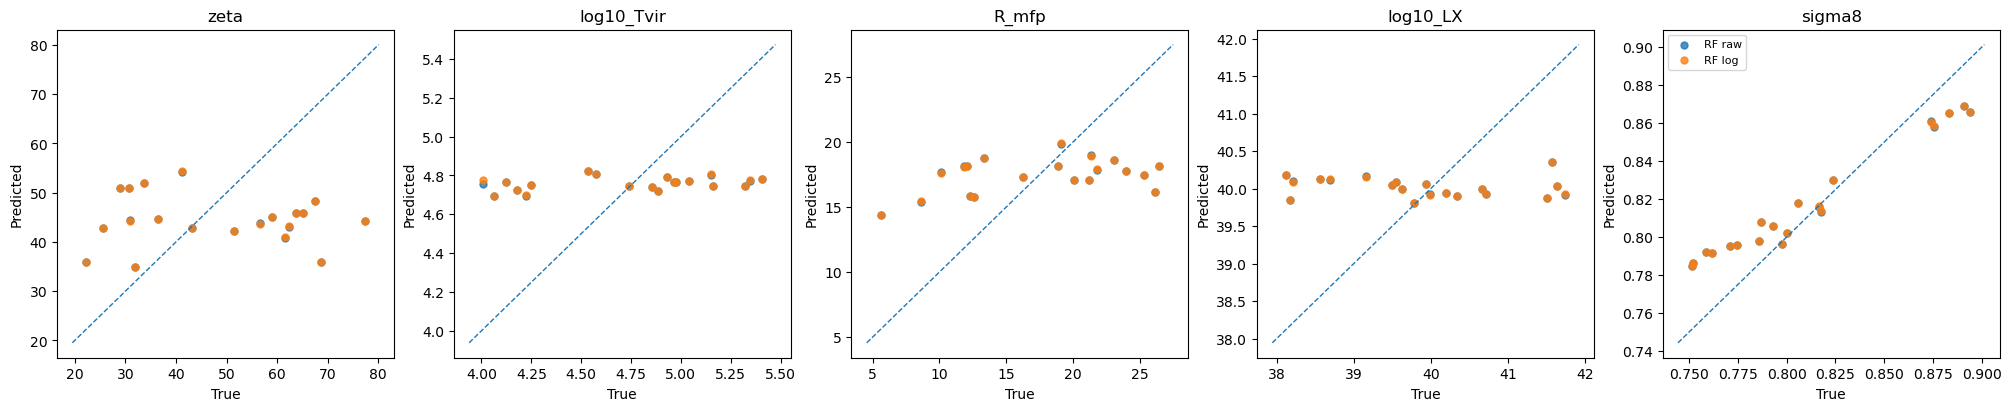

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/rf_pred_vs_true_n100_validation.png


In [17]:
rf_pred_fig_path = FIGURES / f"rf_pred_vs_true_{DATA_TAG}.png"

plot_predicted_vs_true(
    y_true=y_test_raw,
    predictions_dict={
        "RF raw": rf_raw_pred,
        "RF log": rf_log_pred,
    },
    target_names=target_names,
    output_path=rf_pred_fig_path,
)

print("Saved figure to:", rf_pred_fig_path)

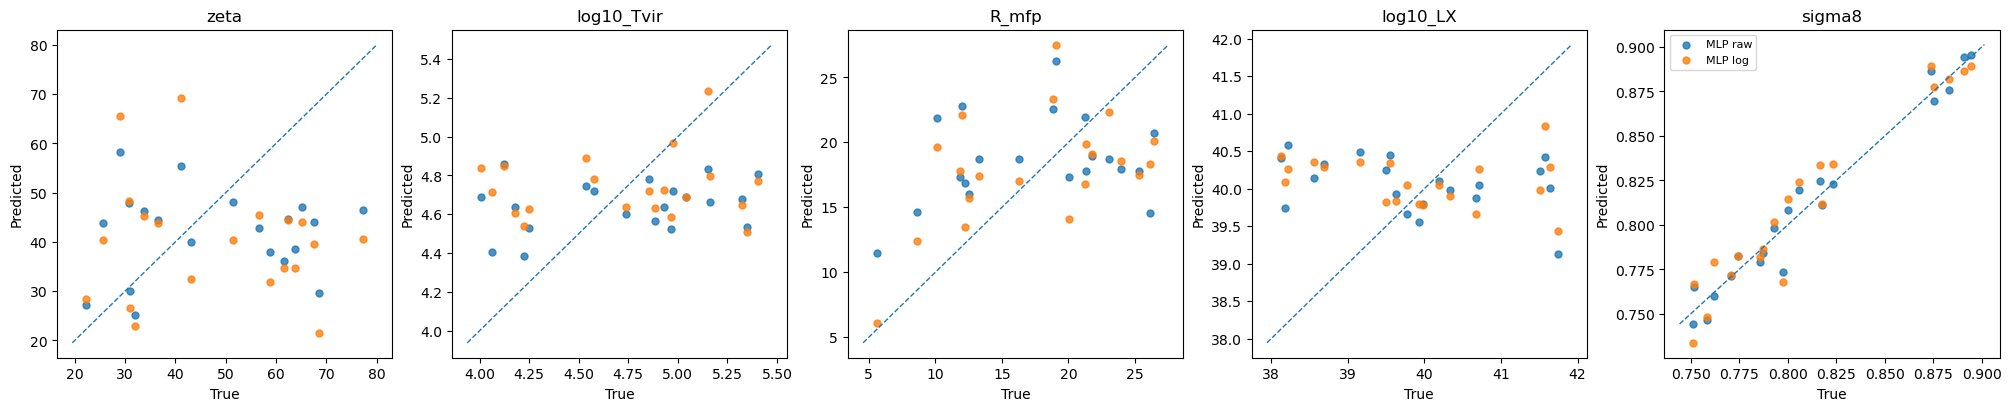

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/mlp_pred_vs_true_n100_validation.png


In [18]:
mlp_pred_fig_path = FIGURES / f"mlp_pred_vs_true_{DATA_TAG}.png"

plot_predicted_vs_true(
    y_true=y_test_raw,
    predictions_dict={
        "MLP raw": mlp_raw_pred,
        "MLP log": mlp_log_pred,
    },
    target_names=target_names,
    output_path=mlp_pred_fig_path,
)

print("Saved figure to:", mlp_pred_fig_path)

In [19]:
best_r2_by_target = (
    baseline_results
    .groupby("target")["r2"]
    .max()
    .sort_values(ascending=False)
)

recoverability_df = best_r2_by_target.reset_index()
recoverability_df.columns = ["target", "best_baseline_r2"]

def classify_recoverability(r2):
    if r2 >= 0.80:
        return "high"
    elif r2 >= 0.50:
        return "moderate"
    elif r2 >= 0.20:
        return "low"
    else:
        return "poor"

recoverability_df["recoverability_class"] = recoverability_df["best_baseline_r2"].apply(
    classify_recoverability
)

recoverability_df

,target,best_baseline_r2,recoverability_class
0,sigma8,0.960441,high
1,R_mfp,0.175866,poor
2,log10_Tvir,0.047715,poor
3,log10_LX,-0.063462,poor
4,zeta,-0.181410,poor


In [20]:
recoverability_path = RESULTS / f"baseline_recoverability_hierarchy_{DATA_TAG}.csv"

recoverability_df.to_csv(recoverability_path, index=False)

print("Saved recoverability hierarchy to:", recoverability_path)

Saved recoverability hierarchy to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/baseline_recoverability_hierarchy_n100_validation.csv


In [21]:
rf_raw_path = RESULTS / f"rf_raw_scaled_{DATA_TAG}.joblib"
rf_log_path = RESULTS / f"rf_log_scaled_{DATA_TAG}.joblib"

mlp_raw_path = RESULTS / f"mlp_raw_scaled_{DATA_TAG}.joblib"
mlp_log_path = RESULTS / f"mlp_log_scaled_{DATA_TAG}.joblib"

joblib.dump(rf_raw, rf_raw_path)
joblib.dump(rf_log, rf_log_path)
joblib.dump(mlp_raw, mlp_raw_path)
joblib.dump(mlp_log, mlp_log_path)

print("Saved models:")
print(" -", rf_raw_path)
print(" -", rf_log_path)
print(" -", mlp_raw_path)
print(" -", mlp_log_path)

Saved models:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/rf_raw_scaled_n100_validation.joblib
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/rf_log_scaled_n100_validation.joblib
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/mlp_raw_scaled_n100_validation.joblib
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/mlp_log_scaled_n100_validation.joblib


In [22]:
baseline_metadata = {
    "notebook": "05_baselines_rf_mlp.ipynb",
    "data_tag": DATA_TAG,
    "n_train": int(X_train_scaled.shape[0]),
    "n_test": int(X_test_scaled.shape[0]),
    "n_features": int(X_train_scaled.shape[1]),
    "n_targets": int(y_train_raw.shape[1]),
    "target_names": target_names,
    "models": {
        "RandomForestRegressor": {
            "n_estimators": 500,
            "min_samples_leaf": 2,
            "random_state": 42,
        },
        "MLPRegressor": {
            "hidden_layer_sizes": [128, 64],
            "alpha": 1e-4,
            "learning_rate_init": 1e-3,
            "max_iter": 2000,
            "early_stopping": True,
            "random_state": 42,
        },
    },
    "feature_representations": [
        "raw_scaled",
        "log_scaled",
    ],
    "notes": (
        "Baseline models are intended to characterize parameter recoverability, "
        "not to serve as fully optimized production estimators. Results from "
        "n=100 should be treated as preliminary."
    ),
}

baseline_metadata_path = RESULTS / f"baseline_metadata_{DATA_TAG}.json"

with open(baseline_metadata_path, "w") as f:
    json.dump(baseline_metadata, f, indent=2)

print("Saved baseline metadata to:", baseline_metadata_path)

Saved baseline metadata to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/baseline_metadata_n100_validation.json


In [23]:
print("=" * 60)
print("Notebook 05 completed successfully.")
print("=" * 60)

print("Dataset tag:", DATA_TAG)
print("Train samples:", X_train_scaled.shape[0])
print("Test samples:", X_test_scaled.shape[0])
print("Features:", X_train_scaled.shape[1])
print("Targets:", y_train_raw.shape[1])

print("\nBest baseline recoverability:")
print(recoverability_df)

print("\nSaved files:")
print(" -", baseline_results_path)
print(" -", r2_table_path)
print(" -", mae_table_path)
print(" -", recoverability_path)
print(" -", r2_fig_path)
print(" -", rf_pred_fig_path)
print(" -", mlp_pred_fig_path)
print(" -", rf_raw_path)
print(" -", rf_log_path)
print(" -", mlp_raw_path)
print(" -", mlp_log_path)
print(" -", baseline_metadata_path)

Notebook 05 completed successfully.
Dataset tag: n100_validation
Train samples: 80
Test samples: 20
Features: 57
Targets: 5

Best baseline recoverability:
       target  best_baseline_r2 recoverability_class
0      sigma8          0.960441                 high
1       R_mfp          0.175866                 poor
2  log10_Tvir          0.047715                 poor
3    log10_LX         -0.063462                 poor
4        zeta         -0.181410                 poor

Saved files:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/baseline_results_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/baseline_r2_table_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/baseline_mae_table_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/baseline_recoverability_hierarchy_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/